# IEEE 8500 — 3-way paper trajectories (4 representative days)

Same figures as before (6-panel |V|+angle at `l3216370`, 10-panel devices), with **three** series:

| Series | Meaning |
|--------|---------|
| **OpenDSS** | Chronological daily march (warm controller carry-over) — Method A |
| **MT-GPS** | Surrogate on the same day profiles |
| **OpenDSS (fixed init)** | Same profiles; before **every** Solve: TapNumber=0, CapControl OFF, CAPBank3 ON (same as training) |

- **Cell 1 (generate):** Method A CSVs (optional skip) + fixed-init OpenDSS merge (`__dss_fixed_*`)
- **Cell 2 (plot):** reads CSVs only → `Figures/fixedctrl3/`


In [3]:
# --- GENERATE: Method A daily (OpenDSS+MT-GPS) + OpenDSS fixed-controller-init ---
# Writes/merges CSVs under outputs/8500_paper_daily_trajectories/day_00*/
%matplotlib inline
from __future__ import annotations

import os
import sys
import time
import numpy as np
from pathlib import Path

def _find_gnn2_repo() -> Path:
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    if Path("/content").is_dir():
        cands.extend([Path("/content/GNN2"), Path("/content/GNN-Sandia")])
    cands.append(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
    cands.append(Path.cwd())
    seen: set[Path] = set()
    for raw in cands:
        p = Path(raw).expanduser().resolve()
        if p in seen:
            continue
        seen.add(p)
        if (p / "run_da_gps_daily_opendss_compare.py").is_file():
            return p
    raise FileNotFoundError("GNN2 repo not found")


REPO = _find_gnn2_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

for _m in (
    "nonunique_notebook_bootstrap",
    "run_da_gps_daily_opendss_compare",
    "run_opendss_fixedctrl_daily",
    "run_original_style_dataset_8500_unbalanced",
):
    sys.modules.pop(_m, None)

from nonunique_notebook_bootstrap import (  # noqa: E402
    FEEDER_RUN_NAMES,
    bootstrap_warmstart_notebook,
    is_colab,
    normalize_feeder_key,
    resolve_cache_pt,
    resolve_feeder_checkpoint,
    resolve_feeder_run_dir,
    resolve_inference_device,
)
from run_da_gps_daily_opendss_compare import run as run_da_gps_daily  # noqa: E402
from run_opendss_fixedctrl_daily import (  # noqa: E402
    merge_fixedctrl_into_day_dir,
    run_fixedctrl_opendss_day,
)

# ── knobs ──────────────────────────────────────────────────────────────────
FEEDER = "8500"
DAYS = (1, 2, 3, 4)  # smoke: DAYS = (4,)
MONITOR_BUSES = ["l3216370"]
DEVICE = "auto"
SMOKE = False
NPTS = 24 if SMOKE else 288
STEP_MIN = 5
# True → skip Method A (reuse existing OD+MT-GPS CSVs); still run fixed-init OD unless skipped
SKIP_METHOD_A = True
SKIP_FIXEDCTRL = False
# per_step = reset before every Solve (required; matches training).
# per_day = optional day-start-only reset (do not use for this figure).
FIXEDCTRL_RESET_MODE = "per_step"
DER_MAX_KW = 0.0
REF_SAMPLE_INDEX = 0
DAILY_STRESS = 0.0
SCENARIO_SCALE = 1.0

RUN_NAME = FEEDER_RUN_NAMES[normalize_feeder_key(FEEDER)]
DAY_DIR = REPO / "a representativ days"
OUT_DIR = REPO / "outputs" / "8500_paper_daily_trajectories"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = resolve_inference_device(DEVICE)
os.environ["GNN_COMPARE_DEVICE"] = DEVICE
if str(DEVICE).lower() == "cpu":
    os.environ["GNN_TORCH_COMPILE"] = "0"
    os.environ.pop("GNN_CUDA_GRAPHS", None)
    os.environ.pop("GNN_DEFER_D2H", None)
else:
    os.environ.setdefault("GNN_CUDA_GRAPHS", "1")
    os.environ.setdefault("GNN_DEFER_D2H", "1")
    os.environ.setdefault("GNN_TORCH_COMPILE", "0")

_on_colab = is_colab() or Path("/content").is_dir()
if _on_colab and not Path("/content/drive/MyDrive").is_dir():
    try:
        from google.colab import drive  # type: ignore

        drive.mount("/content/drive")
    except Exception as _e:  # noqa: BLE001
        print("[gen3] Drive mount skipped:", _e)

try:
    boot = bootstrap_warmstart_notebook(repo=REPO, device=DEVICE, feeder=FEEDER, run_name=RUN_NAME)
    RUN_DIR = Path(boot.run_dir)
    CACHE_PT = Path(boot.cache_pt)
    CHECKPOINT = Path(boot.checkpoint)
    DEVICE = str(boot.device)
except FileNotFoundError as _e:
    print("[gen3] bootstrap fallback:", _e)
    RUN_DIR = resolve_feeder_run_dir(REPO, FEEDER, run_name=RUN_NAME)
    CHECKPOINT = resolve_feeder_checkpoint(RUN_DIR)
    CACHE_PT = resolve_cache_pt(REPO, feeder=FEEDER)

PLOT_NODES = [f"{b}.{ph}" for b in MONITOR_BUSES for ph in (1, 2, 3)]
print("=" * 72)
print(f"[gen3] DAYS={DAYS} NPTS={NPTS} SKIP_METHOD_A={SKIP_METHOD_A} SKIP_FIXEDCTRL={SKIP_FIXEDCTRL} RESET_MODE={FIXEDCTRL_RESET_MODE}")
print(f"[gen3] MONITOR={MONITOR_BUSES}  PLOT_NODES={PLOT_NODES}")
print(f"[gen3] RUN_DIR={RUN_DIR}")
print(f"[gen3] CHECKPOINT={CHECKPOINT}")
print(f"[gen3] CACHE_PT={CACHE_PT}")
print(f"[gen3] OUT_DIR={OUT_DIR}")
print("=" * 72)


def _day_paths(day: int) -> tuple[Path, Path]:
    load_p = DAY_DIR / f"load_day_{int(day):03d}.csv"
    irr_p = DAY_DIR / f"irr_day_{int(day):03d}.csv"
    if not load_p.is_file():
        raise FileNotFoundError(load_p)
    if not irr_p.is_file():
        raise FileNotFoundError(irr_p)
    return load_p, irr_p


def _day_out(day: int) -> Path:
    return OUT_DIR / f"day_{int(day):03d}"


def _install_voltage_csv_hook(day_out: Path, plot_nodes: list[str]):
    """Capture Method A voltage PNG savefig series into daily_voltage_monitor.csv."""
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    orig_savefig = plt.savefig
    captured: dict[str, dict[str, np.ndarray]] = {}
    want = {str(n).lower() for n in plot_nodes}

    def _hooked(fname, *args, **kwargs):  # noqa: ANN001
        try:
            fig = plt.gcf()
            axes = fig.get_axes()
            if not axes:
                return orig_savefig(fname, *args, **kwargs)
            # Method A voltage figures: title / legend often carry node name
            title = " ".join(str(getattr(ax, "get_title", lambda: "")()) for ax in axes).lower()
            node = None
            for n in want:
                if n in title or n.replace(".", "_") in title:
                    node = n
                    break
            # fallback: parse filename v_*_bus_phase.png
            fp = str(fname).lower()
            if node is None:
                for n in want:
                    if n.replace(".", "_") in fp or n in fp:
                        node = n
                        break
            if node is not None and axes:
                ax = axes[0]
                lines = ax.get_lines()
                if len(lines) >= 2:
                    x = np.asarray(lines[0].get_xdata(), dtype=np.float64)
                    # OpenDSS solid first, MT-GPS dashed second (Method A convention)
                    od = np.asarray(lines[0].get_ydata(), dtype=np.float64)
                    gn = np.asarray(lines[1].get_ydata(), dtype=np.float64)
                    pack = captured.setdefault(node, {})
                    pack["hour"] = x
                    pack["opendss"] = od
                    pack["mt_gps"] = gn
                    # angle panel if present
                    if len(axes) >= 2 and len(axes[1].get_lines()) >= 2:
                        pack["opendss_ang"] = np.asarray(axes[1].get_lines()[0].get_ydata(), dtype=np.float64)
                        pack["mt_gps_ang"] = np.asarray(axes[1].get_lines()[1].get_ydata(), dtype=np.float64)
        except Exception:
            pass
        return orig_savefig(fname, *args, **kwargs)

    plt.savefig = _hooked  # type: ignore[assignment]

    def _restore_and_write():
        plt.savefig = orig_savefig  # type: ignore[assignment]
        if not captured:
            print(f"[gen3] WARNING: no monitor |V| captured under {day_out}")
            return None
        hour = next(iter(captured.values()))["hour"]
        rows: dict[str, object] = {
            "step_idx": list(range(len(hour))),
            "hour": hour.astype(np.float64).tolist(),
        }
        for nk, pack in captured.items():
            stem = nk.replace(".", "_")
            rows[f"{nk}__dss_vmag_pu"] = pack["opendss"].tolist()
            rows[f"{nk}__gnn_vmag_pu"] = pack["mt_gps"].tolist()
            rows[f"{stem}__dss_vmag_pu"] = pack["opendss"].tolist()
            rows[f"{stem}__gnn_vmag_pu"] = pack["mt_gps"].tolist()
            if "opendss_ang" in pack:
                rows[f"{nk}__dss_vang_deg"] = pack["opendss_ang"].tolist()
                rows[f"{nk}__gnn_vang_deg"] = pack["mt_gps_ang"].tolist()
                rows[f"{stem}__dss_vang_deg"] = pack["opendss_ang"].tolist()
                rows[f"{stem}__gnn_vang_deg"] = pack["mt_gps_ang"].tolist()
        csv_path = day_out / "daily_voltage_monitor.csv"
        # merge with existing if present (keep prior columns)
        if csv_path.is_file():
            old = pd.read_csv(csv_path)
            new = pd.DataFrame(rows)
            for c in new.columns:
                old[c] = new[c]
            old.to_csv(csv_path, index=False)
        else:
            pd.DataFrame(rows).to_csv(csv_path, index=False)
        print(f"[gen3] wrote/merged {csv_path} nodes={sorted(captured)}")
        return csv_path

    return _restore_and_write


def _run_method_a_day(day: int) -> Path:
    day_out = _day_out(day)
    day_out.mkdir(parents=True, exist_ok=True)
    load_p, irr_p = _day_paths(day)
    restore = _install_voltage_csv_hook(day_out, PLOT_NODES)
    print(f"\n[gen3] === Method A Day {day}: {load_p.name} / {irr_p.name} ===", flush=True)
    try:
        run_da_gps_daily(
            run_dir=RUN_DIR,
            cache_pt=CACHE_PT,
            out_dir=day_out,
            checkpoint=CHECKPOINT,
            edge_csv=None,
            daily_profile_csv=None,
            plot_nodes=list(PLOT_NODES),
            plot_all_cache_nodes=False,
            npts=int(NPTS),
            step_min=int(STEP_MIN),
            daily_stress=float(DAILY_STRESS),
            scenario_scale=float(SCENARIO_SCALE),
            stress_clip_lo=0.1,
            stress_clip_hi=3.0,
            ref_sample_index=int(REF_SAMPLE_INDEX),
            mv_sx_mapping=None,
            ymin=0.92,
            ymax=1.08,
            v_ylim_fixed=False,
            show_plots=False,
            device=DEVICE,
            load_profile_path=str(load_p),
            load_profile_filename=load_p.name,
            pv_irradiance_profile_path=str(irr_p),
            pv_irradiance_filename=irr_p.name,
            der_max_kw=float(DER_MAX_KW),
            der_buses="",
            feeder=FEEDER,
        )
    finally:
        restore()
    return day_out


def _run_fixedctrl_day(day: int) -> Path:
    day_out = _day_out(day)
    day_out.mkdir(parents=True, exist_ok=True)
    load_p, irr_p = _day_paths(day)
    print(f"\n[gen3] === Fixed-init OpenDSS Day {day}: {load_p.name} / {irr_p.name} ===", flush=True)
    t0 = time.time()
    result = run_fixedctrl_opendss_day(
        reset_mode=str(FIXEDCTRL_RESET_MODE),
        load_csv=load_p,
        irr_csv=irr_p,
        npts=int(NPTS),
        step_min=int(STEP_MIN),
        scenario_scale=float(SCENARIO_SCALE),
        daily_stress=float(DAILY_STRESS),
        monitor_nodes=list(PLOT_NODES),
    )
    written = merge_fixedctrl_into_day_dir(day_out, result)
    n_skip = int(result.get("n_skipped", 0) or 0)
    n_ok = int(np.sum(result["converged"])) if result.get("converged") is not None else -1
    print(f"[gen3] fixedctrl day {day}: ok={n_ok} skipped={n_skip} (left as NaN gaps; not shown as real values)")
    print(
        f"[gen3] fixedctrl day {day} done in {(time.time()-t0)/60:.1f} min | "
        f"converged={int(result['converged'].sum())}/{NPTS} | wrote {list(written)}"
    )
    return day_out


# ── run ─────────────────────────────────────────────────────────────────────
if not SKIP_METHOD_A:
    if not CHECKPOINT.is_file():
        raise FileNotFoundError(CHECKPOINT)
    if not CACHE_PT.is_file():
        raise FileNotFoundError(CACHE_PT)
    for d in DAYS:
        _run_method_a_day(int(d))
else:
    print("[gen3] SKIP_METHOD_A=True — reusing existing Method A CSVs")

if not SKIP_FIXEDCTRL:
    for d in DAYS:
        _run_fixedctrl_day(int(d))
else:
    print("[gen3] SKIP_FIXEDCTRL=True — not regenerating fixed-init OpenDSS")

print("\n[gen3] done.")
for d in DAYS:
    p = _day_out(int(d))
    print(f"  day {d}: {p}")
    for pat in (
        "daily_voltage_monitor.csv",
        "daily_regulator_tap_*.csv",
        "daily_cap_bank_status_*.csv",
        "daily_meta_aux_*.csv",
        "fixedctrl_opendss_summary.json",
    ):
        hits = sorted(p.glob(pat))
        print(f"    {pat}: {[h.name for h in hits]}")


[bootstrap] env=local  repo=C:\Users\alita\OneDrive\Desktop\GNN2
[bootstrap] feeder=8500  device=cpu  cache=run_001_scen_0000_0049_seed_20420233__full__nobess__regce__mauxb7bd1d58.pt
[bootstrap] checkpoint=K:\My Drive\datasets_gnn2\runs\da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE\training_last.pt
[bootstrap] out_dir=C:\Users\alita\OneDrive\Desktop\GNN2\warmstart_band_runs\20260910_162247
[gen3] DAYS=(1, 2, 3, 4) NPTS=288 SKIP_METHOD_A=True SKIP_FIXEDCTRL=False RESET_MODE=per_step
[gen3] MONITOR=['l3216370']  PLOT_NODES=['l3216370.1', 'l3216370.2', 'l3216370.3']
[gen3] RUN_DIR=K:\My Drive\datasets_gnn2\runs\da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE
[gen3] CHECKPOINT=K:\My Drive\datasets_gnn2\runs\da_gps_chunked_l4_mvagg_gine_metaaux_regce_20260516_225149_CCE\training_last.pt
[gen3] CACHE_PT=C:\Users\alita\OneDrive\Desktop\GNN2\datasets_gnn2_from pc\run_001_scen_0000_0049_seed_20420233__full__nobess__regce__mauxb7bd1d58.pt
[gen3] OUT_DIR=C:\Users\a

[plot3] dss_fixed voltage columns: 12
[compact] OUT_DIR=C:\Users\alita\OneDrive\Desktop\GNN2\outputs\8500_paper_daily_trajectories
[compact] voltage buses in CSV: ['l3216370']
[compact] buses with Method A PNGs (day 4): ['190-8593', 'l2814529', 'l2841632', 'l3216370', 'l3235256']
[compact] using capacitor bank capbank1 A/B/C
[compact] will plot capacitor banks: ['capbank1']

[compact] |V|+angle figure for 'l3216370'
[angle] 'l3216370' plotted in degrees; span=[-161, 87.7]
[compact] saved C:\Users\alita\OneDrive\Desktop\GNN2\Figures\fixedctrl3\voltage_trajectories_l3216370_3way.pdf
[compact] saved C:\Users\alita\OneDrive\Desktop\GNN2\Figures\fixedctrl3\voltage_trajectories_l3216370_3way.svg
[compact] saved C:\Users\alita\OneDrive\Desktop\GNN2\Figures\fixedctrl3\voltage_mag_angle_l3216370_3way.pdf
[compact] saved C:\Users\alita\OneDrive\Desktop\GNN2\Figures\fixedctrl3\voltage_mag_angle_l3216370_3way.svg


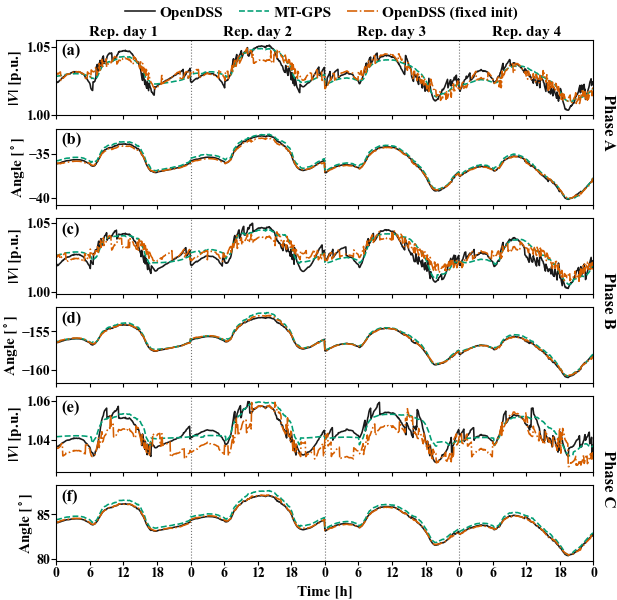


[compact] device figure with capbank1 A/B/C
[compact] saved C:\Users\alita\OneDrive\Desktop\GNN2\Figures\fixedctrl3\device_trajectories_capbank1_3way.pdf
[compact] saved C:\Users\alita\OneDrive\Desktop\GNN2\Figures\fixedctrl3\device_trajectories_capbank1_3way.svg


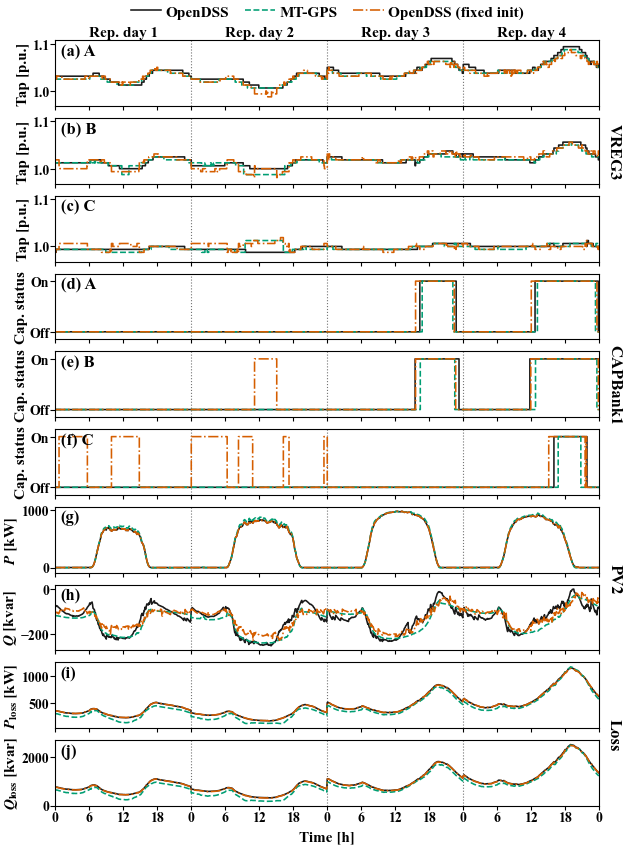


[plot3] done — 3-way OpenDSS / MT-GPS / OpenDSS (fixed init).
[plot3] outputs under C:\Users\alita\OneDrive\Desktop\GNN2\Figures\fixedctrl3
[compact] tip: change MONITOR_BUSES / FIG_H_* / CAP_BANK and re-run this cell only.


In [4]:
# --- PLOT: 3-way paper trajectories (OpenDSS / MT-GPS / OpenDSS fixed init) ---
# Reads day_*/ CSVs with __dss_fixed_* columns from the generate cell.
%matplotlib inline
from __future__ import annotations

import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display


def _find_gnn2_repo() -> Path:
    cands: list[Path] = []
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    if env:
        cands.append(Path(env))
    if Path("/content").is_dir():
        cands.extend([Path("/content/GNN2"), Path("/content/GNN-Sandia")])
    cands.append(Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"))
    cands.append(Path.cwd())
    seen: set[Path] = set()
    for raw in cands:
        p = raw.expanduser().resolve()
        if p in seen:
            continue
        seen.add(p)
        if (p / "run_da_gps_daily_opendss_compare.py").is_file():
            return p
    raise FileNotFoundError("GNN2 repo root not found")


REPO = _find_gnn2_repo()
OUT_DIR = REPO / "outputs" / "8500_paper_daily_trajectories"
FIG_DIR = REPO / "Figures" / "fixedctrl3"
DAYS = (1, 2, 3, 4)
STEP_MIN = 5

# ── knobs (edit these; never re-solves) ─────────────────────────────────────
MONITOR_BUSES = ["l3216370"]  # must be in daily_voltage_monitor.csv
CAP_BANKS = ["capbank1"]  # keep CAPBank1 A/B/C only for the device figure
DAY_BAND_LABEL = "Rep. day"
META_AUX_PANELS: list[tuple[str, str, str, str]] = [
    # (csv_stem, panel_letter, ylabel, right_group_label)
    ("pv_pv2_p_post_kw", "g", r"$P$ [kW]", "PV2"),
    ("pv_pv2_q_post_kvar", "h", r"$Q$ [kvar]", "PV2"),
    ("p_loss_total_post_kw", "i", r"$P_\mathrm{loss}$ [kW]", "Loss"),
    ("q_loss_total_post_kvar", "j", r"$Q_\mathrm{loss}$ [kvar]", "Loss"),
]
N_META_AUX = len(META_AUX_PANELS)
FIG_W = 6.8
FIG_H_VOLTAGE = 3.2   # shorter *panels* than cell 91 (~5.0); keep real hspace below
FIG_H_DEVICE = 8.8    # 10 device panels (VREG3 + CAPBank + meta-aux)
HSPACE = 0.18         # gap between panels (do NOT shrink this to squeeze height)
OUT_TAG = "_3way"
SHOW_PNG_PREVIEWS = False  # show existing Method A v_*.png for other buses
PNG_PREVIEW_DAY = 4       # which day folder to preview
PNG_PREVIEW_BUSES = ["l2841632", "190-8593", "l2814529", "l3235256"]  # not in CSV yet

COLOR_OPENDSS = "0.10"
COLOR_MTGPS = "#009E73"
COLOR_FIXED = "#D55E00"
LS_OPENDSS = "-"
LS_MTGPS = "--"
LS_FIXED = "-."
LW_OPENDSS = 1.15
LW_MTGPS = 1.15
LW_FIXED = 1.15
LABELS_3 = ["OpenDSS", "MT-GPS", "OpenDSS (fixed init)"]

FIG_DIR.mkdir(parents=True, exist_ok=True)


def _setup_ieee_fonts() -> None:
    plt.rcParams.update(
        {
            "font.family": "serif",
            "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
            "mathtext.fontset": "stix",
            "font.size": 11,
            "font.weight": "bold",
            "axes.labelweight": "bold",
            "axes.titleweight": "bold",
            "axes.labelsize": 11,
            "axes.titlesize": 12,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "legend.fontsize": 11,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "svg.fonttype": "none",
            "axes.grid": False,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "figure.facecolor": "white",
            "axes.facecolor": "white",
        }
    )


def _day_out(day: int) -> Path:
    return OUT_DIR / f"day_{int(day):03d}"


def _glob_one(day_out: Path, pattern: str) -> Path:
    hits = sorted(day_out.glob(pattern))
    if not hits:
        raise FileNotFoundError(f"No {pattern} under {day_out}")
    return hits[0]


def _available_voltage_buses(df: pd.DataFrame) -> list[str]:
    buses: set[str] = set()
    for c in df.columns:
        cl = str(c)
        if "__dss_vmag" not in cl.lower():
            continue
        stem = cl.split("__", 1)[0]
        # prefer dotted bus.phase form
        if "." in stem:
            buses.add(stem.rsplit(".", 1)[0])
        elif "_" in stem and stem[-1] in "123":
            buses.add(stem.rsplit("_", 1)[0])
    return sorted(buses)


def _png_preview_buses(day: int) -> list[str]:
    buses: set[str] = set()
    for p in _day_out(day).glob("v_*.png"):
        m = re.search(r"_([A-Za-z0-9-]+)_([123])\.png$", p.name)
        if m:
            buses.add(m.group(1))
    return sorted(buses)


def _load_day_tables(day: int) -> dict[str, pd.DataFrame]:
    day_out = _day_out(day)
    volt = day_out / "daily_voltage_monitor.csv"
    if not volt.is_file():
        raise FileNotFoundError(f"Missing {volt}")
    return {
        "volt": pd.read_csv(volt),
        "reg": pd.read_csv(_glob_one(day_out, "daily_regulator_tap_*.csv")),
        "cap": pd.read_csv(_glob_one(day_out, "daily_cap_bank_status_*.csv")),
        "meta": pd.read_csv(_glob_one(day_out, "daily_meta_aux_*.csv")),
    }


def _fixed_token(dss_key: str) -> str:
    """Map Method-A DSS token → fixed-init column token (dss_vmag → dss_fixed_vmag)."""
    k = str(dss_key).lower()
    if k.startswith("dss_fixed"):
        return k
    if k.startswith("dss_"):
        return "dss_fixed_" + k[len("dss_") :]
    if k == "dss":
        return "dss_fixed"
    return "dss_fixed"


def _pick_col(df: pd.DataFrame, stem: str, *, token: str, exclude_fixed: bool = False) -> str | None:
    stem_l = str(stem).lower()
    alt = stem_l.replace(".", "_")
    tok = str(token).lower()
    cands: list[str] = []
    for c in df.columns:
        cl = str(c).lower()
        head = cl.split("__", 1)[0]
        if head not in (stem_l, alt) and stem_l not in cl and alt not in cl:
            continue
        if tok not in cl:
            continue
        if exclude_fixed and "dss_fixed" in cl:
            continue
        cands.append(str(c))
    if not cands:
        return None
    for c in cands:
        cl = str(c).lower()
        if cl.startswith(stem_l + "__") or cl.startswith(alt + "__"):
            return c
    return cands[0]


def _series_triple(
    df: pd.DataFrame,
    stem: str,
    *,
    dss_key: str = "dss",
    gnn_key: str = "gnn",
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    od_c = _pick_col(df, stem, token=dss_key, exclude_fixed=True)
    gn_c = _pick_col(df, stem, token=gnn_key)
    fx_c = _pick_col(df, stem, token=_fixed_token(dss_key))
    if od_c is None or gn_c is None:
        raise KeyError(
            f"Missing DSS/GNN for stem={stem!r} (od={od_c}, gn={gn_c}, keys={dss_key}/{gnn_key})"
        )
    od = np.asarray(df[od_c], dtype=np.float64)
    gn = np.asarray(df[gn_c], dtype=np.float64)
    fx = np.full_like(od, np.nan) if fx_c is None else np.asarray(df[fx_c], dtype=np.float64)
    return od, gn, fx


def _series_pair(
    df: pd.DataFrame, stem: str, *, dss_key: str = "dss", gnn_key: str = "gnn"
) -> tuple[np.ndarray, np.ndarray]:
    od, gn, _fx = _series_triple(df, stem, dss_key=dss_key, gnn_key=gnn_key)
    return od, gn



def _hour_axis(df: pd.DataFrame) -> np.ndarray:
    if "hour" in df.columns:
        return np.asarray(df["hour"], dtype=np.float64)
    n = len(df)
    return np.arange(n, dtype=np.float64) * (float(STEP_MIN) / 60.0)


def _concat_days(
    day_tables: dict[int, dict[str, pd.DataFrame]],
    kind: str,
    stem: str,
    *,
    dss_key: str = "dss",
    gnn_key: str = "gnn",
    binary_cap: bool = False,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, list[float]]:
    xs: list[np.ndarray] = []
    ods: list[np.ndarray] = []
    gns: list[np.ndarray] = []
    fxs: list[np.ndarray] = []
    seps: list[float] = []
    x_off = 0.0
    for di, day in enumerate(DAYS):
        df = day_tables[day][kind]
        h = _hour_axis(df)
        od, gn, fx = _series_triple(df, stem, dss_key=dss_key, gnn_key=gnn_key)
        if binary_cap:
            od = (np.nan_to_num(od, nan=0.0) > 0.5).astype(np.float64)
            gn = (np.nan_to_num(gn, nan=0.0) >= 0.5).astype(np.float64)
            # Keep NaN for skipped (controller not settled) — do not draw as Off.
            fx_bin = np.full_like(fx, np.nan, dtype=np.float64)
            _m = np.isfinite(fx)
            fx_bin[_m] = (fx[_m] > 0.5).astype(np.float64)
            fx = fx_bin
        xs.append(h + x_off)
        ods.append(od)
        gns.append(gn)
        fxs.append(fx)
        next_off = x_off + 24.0
        if di < len(DAYS) - 1:
            seps.append(next_off)
        x_off = next_off
    return np.concatenate(xs), np.concatenate(ods), np.concatenate(gns), np.concatenate(fxs), seps


def _count_transitions(y: np.ndarray) -> int:
    y = np.asarray(y, dtype=np.float64)
    m = np.isfinite(y)
    if int(m.sum()) < 2:
        return 0
    yy = y[m]
    return int(np.sum(np.abs(np.diff(yy)) > 1e-9))


def _select_cap_bank_phases(
    day_tables: dict[int, dict[str, pd.DataFrame]],
    cap_bank: str,
) -> tuple[str, list[tuple[str, str, str]]]:
    sample = day_tables[DAYS[0]]["cap"]
    stems: list[str] = []
    for c in sample.columns:
        cl = str(c)
        if "__dss_" not in cl.lower():
            continue
        stem = cl.split("__", 1)[0]
        if stem.lower().startswith("cap_"):
            stems.append(stem)
    stems = list(dict.fromkeys(stems))
    fam: dict[str, dict[str, str]] = {}
    for stem in stems:
        m = re.match(r"(?i)cap_(capbank\d+)([abc])_n_steps_on$", stem)
        if not m:
            continue
        bank, ph = m.group(1).lower(), m.group(2).lower()
        fam.setdefault(bank, {})[ph] = stem
    complete = {b: phs for b, phs in fam.items() if set(phs) >= {"a", "b", "c"}}
    if not complete:
        raise RuntimeError("No CAPBank0/1/2 A/B/C families in cap CSV")

    want = str(cap_bank).strip().lower()
    if want and want != "auto":
        if want not in complete:
            raise KeyError(f"CAP_BANK={cap_bank!r} not in {sorted(complete)}")
        best_bank = want
    else:
        scores: list[tuple[int, int, str]] = []
        for bank, phs in complete.items():
            n_sw = n_on = 0
            for ph in ("a", "b", "c"):
                for day in DAYS:
                    od, _gn = _series_pair(day_tables[day]["cap"], phs[ph], dss_key="dss", gnn_key="gnn")
                    od_bin = (np.nan_to_num(od, nan=0.0) > 0.5).astype(np.float64)
                    n_sw += _count_transitions(od_bin)
                    n_on += int(np.nansum(od_bin))
            scores.append((n_sw, n_on, bank))
        scores.sort(key=lambda t: (t[0], t[1]), reverse=True)
        best_bank = scores[0][2]
        print(f"[compact] auto CAP bank rank={[(s[2], s[0]) for s in scores]}")

    phs = complete[best_bank]
    bank_pretty = best_bank.upper().replace("CAPBANK", "CAPBank")
    panels = [(phs[ph], f"{bank_pretty}-{ph.upper()}", ph.upper()) for ph in ("a", "b", "c")]
    print(f"[compact] using capacitor bank {best_bank} A/B/C")
    return best_bank, panels


def _add_day_separators(ax, seps: list[float], *, label_top: bool) -> None:
    xmax = 24.0 * len(DAYS)
    for s in seps:
        ax.axvline(s, color="0.45", ls=":", lw=0.8, zorder=0)
    if label_top:
        for i, day in enumerate(DAYS):
            xc = 24.0 * i + 12.0
            ax.text(
                xc,
                1.02,
                f"{DAY_BAND_LABEL} {day}",
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="bottom",
                fontname="Times New Roman",
                fontsize=11,
                fontweight="bold",
                clip_on=False,
            )
    ax.set_xlim(0.0, xmax)


def _panel_label(ax, letter: str, phase: str | None = None) -> None:
    txt = f"({letter})" if not phase else f"({letter}) {phase}"
    ax.text(
        0.01,
        0.95,
        txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontname="Times New Roman",
        fontsize=12,
        fontweight="bold",
    )


def _style_axes_ieee(ax) -> None:
    ax.tick_params(axis="both", labelsize=10, pad=1)
    for _tl in ax.get_xticklabels() + ax.get_yticklabels():
        _tl.set_fontname("Times New Roman")
        _tl.set_fontweight("bold")


TRAJ_LEGEND_GAP_FIG = 0.004  # gap above Rep. day row (match voltage figure)


def _shared_legend(fig, handles, labels, *, ax_top=None) -> None:
    """OpenDSS / MT-GPS legend; optional ax_top aligns gap above Rep. day labels."""
    bbox_y = 1.01
    legend_loc = "upper center"
    if ax_top is not None:
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        rep_tops: list[float] = []
        for _t in ax_top.texts:
            if str(_t.get_text()).startswith(DAY_BAND_LABEL):
                _bb = _t.get_window_extent(renderer)
                rep_tops.append(
                    float(fig.transFigure.inverted().transform((0.0, _bb.y1))[1])
                )
        if rep_tops:
            bbox_y = max(rep_tops) + TRAJ_LEGEND_GAP_FIG
            legend_loc = "lower center"
    leg = fig.legend(
        handles,
        labels,
        loc=legend_loc,
        ncol=len(labels),
        frameon=False,
        fancybox=False,
        edgecolor="0.4",
        fontsize=11,
        borderpad=0.25,
        handletextpad=0.3,
        columnspacing=1.0,
        bbox_to_anchor=(0.5, bbox_y),
        bbox_transform=fig.transFigure,
        borderaxespad=0.0,
    )
    for _t in leg.get_texts():
        _t.set_fontname("Times New Roman")
        _t.set_fontweight("bold")
    return leg


def _save_fig(fig, stem: str) -> list[Path]:
    outs: list[Path] = []
    for ext in (".pdf", ".svg"):
        p = FIG_DIR / f"{stem}{ext}"
        fig.savefig(p)
        outs.append(p)
        print(f"[compact] saved {p}")
    return outs


# ── load CSVs ───────────────────────────────────────────────────────────────
for d in DAYS:
    if not _day_out(d).is_dir():
        raise FileNotFoundError(f"Missing {_day_out(d)} — run cell 91 once first.")

day_tables = {int(d): _load_day_tables(int(d)) for d in DAYS}

_fx_cols = [c for c in day_tables[DAYS[0]]["volt"].columns if "dss_fixed" in str(c).lower()]
if not _fx_cols:
    raise FileNotFoundError(
        "No __dss_fixed_* columns found. Run the GENERATE cell first (SKIP_FIXEDCTRL=False)."
    )
print(f"[plot3] dss_fixed voltage columns: {len(_fx_cols)}")

avail = _available_voltage_buses(day_tables[DAYS[0]]["volt"])
png_buses = _png_preview_buses(int(PNG_PREVIEW_DAY))
print(f"[compact] OUT_DIR={OUT_DIR}")
print(f"[compact] voltage buses in CSV: {avail}")
print(f"[compact] buses with Method A PNGs (day {PNG_PREVIEW_DAY}): {png_buses}")

missing = [b for b in MONITOR_BUSES if b not in avail]
if missing:
    raise KeyError(
        f"MONITOR_BUSES not in daily_voltage_monitor.csv: {missing}. "
        f"Available={avail}. For other buses, either set SHOW_PNG_PREVIEWS or "
        f"re-run cell 91 once with those buses in MONITOR_BUSES (that re-solves)."
    )

# Resolve which bank families to plot
_cap_req = list(CAP_BANKS)
if len(_cap_req) == 1 and str(_cap_req[0]).strip().lower() == "auto":
    _cap_bank_list = ["auto"]
else:
    _cap_bank_list = [str(x).strip().lower() for x in _cap_req]

cap_jobs: list[tuple[str, list[tuple[str, str, str]]]] = []
_seen_banks: set[str] = set()
for _cb in _cap_bank_list:
    _bank, _panels = _select_cap_bank_phases(day_tables, _cb)
    if _bank in _seen_banks:
        continue
    _seen_banks.add(_bank)
    cap_jobs.append((_bank, _panels))
print(f"[compact] will plot capacitor banks: {[b for b, _ in cap_jobs]}")
reg_stems = [f"reg_vreg3_{ph}_tap_pu" for ph in ("a", "b", "c")]

_setup_ieee_fonts()
xticks: list[float] = []
xlabels: list[str] = []
for i in range(len(DAYS)):
    for h in (0, 6, 12, 18):
        xticks.append(24.0 * i + h)
        xlabels.append(str(h))
xticks.append(24.0 * len(DAYS))
xlabels.append("0")

# ── voltage figures: Phase A/B/C |V| then angle (6 panels, one figure) ─
def _bus_has_angle(bus: str) -> bool:
    sample = day_tables[DAYS[0]]["volt"]
    try:
        _series_pair(sample, f"{bus}.1", dss_key="dss_vang", gnn_key="gnn_vang")
        return True
    except KeyError:
        return False

def _tight_ylim(ax, *ys, frac: float = 0.08, min_pad: float | None = None) -> None:
    """Per-panel y-limits from plotted series only (tight + small pad)."""
    vals = np.concatenate(
        [np.asarray(y, dtype=float).ravel() for y in ys if y is not None]
    ) if ys else np.asarray([], dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return
    lo, hi = float(vals.min()), float(vals.max())
    span = hi - lo
    if min_pad is None:
        # |V| ~1 p.u. vs angle in degrees (often |θ|≫10 on B/C)
        min_pad = 1e-3 if abs(hi) < 10 and abs(lo) < 10 else 0.5
    pad = max(span * float(frac), float(min_pad))
    ax.set_ylim(lo - pad, hi + pad)

def _force_angle_degrees(*series: np.ndarray) -> list[np.ndarray]:
    """Return angle series in degrees. Convert from radians if values look like rad."""
    arrs = [np.asarray(s, dtype=np.float64) for s in series]
    finite = np.concatenate([a[np.isfinite(a)] for a in arrs if a.size]) if arrs else np.array([])
    if finite.size == 0:
        return arrs
    # OpenDSS/MT-GPS feeder angles in deg typically reach |θ|≫π on phases B/C.
    # If everything stays within ~π, treat as radians and convert.
    if float(np.nanmax(np.abs(finite))) <= (np.pi + 0.25):
        arrs = [np.rad2deg(a) for a in arrs]
    return arrs

def _plot_voltage_mag_angle(bus: str, *, fig_h: float, hspace: float, out_stem: str, also_alias: bool = False) -> list:
    """(a)–(f) interleaved |V|/angle; Phase A/B/C once per pair — per-panel y-limits."""
    _plot_voltage_mag_angle._ang_cache = None  # type: ignore[attr-defined]
    if not _bus_has_angle(bus):
        raise KeyError(
            f"No angle columns for {bus!r} in daily_voltage_monitor.csv. "
            "Re-run cell 91 once with SKIP_DAILY_RUNS=False "
            "(Method A now writes |V| + angle)."
        )
    fig_v, axes_v = plt.subplots(
        6, 1, sharex=True, figsize=(FIG_W, fig_h), gridspec_kw={"hspace": hspace}
    )
    legend_handles = None
    letters = ("a", "b", "c", "d", "e", "f")
    row = 0
    for ph, ph_letter in zip((1, 2, 3), ("A", "B", "C")):
        node = f"{bus}.{ph}"
        ax = axes_v[row]
        x, od, gn, fx, seps = _concat_days(day_tables, "volt", node, dss_key="dss_vmag", gnn_key="gnn_vmag")
        (h0,) = ax.plot(x, od, color=COLOR_OPENDSS, ls=LS_OPENDSS, lw=LW_OPENDSS, label="OpenDSS")
        (h1,) = ax.plot(x, gn, color=COLOR_MTGPS, ls=LS_MTGPS, lw=LW_MTGPS, label="MT-GPS")
        (h2,) = ax.plot(x, fx, color=COLOR_FIXED, ls=LS_FIXED, lw=LW_FIXED, label="OpenDSS (fixed init)")
        if legend_handles is None:
            legend_handles = (h0, h1, h2)
        ax.set_ylabel(r"$|V|$ [p.u.]", fontname="Times New Roman", fontsize=11, labelpad=1, fontweight="bold")
        _tight_ylim(ax, od, gn, fx, frac=0.08, min_pad=1e-3)
        _panel_label(ax, letters[row])
        _add_day_separators(ax, seps, label_top=(row == 0))
        _style_axes_ieee(ax)
        row += 1
        ax = axes_v[row]
        # Force degrees for this phase (and siblings) once per figure via cache
        _ac0 = getattr(_plot_voltage_mag_angle, "_ang_cache", None)
        if not isinstance(_ac0, dict) or _ac0.get("bus") != bus:
            _pack = []
            _od_m, _gn_m, _fx_m = {}, {}, {}
            _xx = _ss = None
            for _ph in (1, 2, 3):
                _xx, _o, _g, _f, _ss = _concat_days(
                    day_tables, "volt", f"{bus}.{_ph}", dss_key="dss_vang", gnn_key="gnn_vang"
                )
                _od_m[_ph], _gn_m[_ph], _fx_m[_ph] = _o, _g, _f
                _pack.extend([_o, _g, _f])
            _pack = _force_angle_degrees(*_pack)
            for _k, _ph in enumerate((1, 2, 3)):
                _od_m[_ph] = _pack[3 * _k]
                _gn_m[_ph] = _pack[3 * _k + 1]
                _fx_m[_ph] = _pack[3 * _k + 2]
            _plot_voltage_mag_angle._ang_cache = {
                "bus": bus, "x": _xx, "seps": _ss, "od": _od_m, "gn": _gn_m, "fx": _fx_m
            }
            print(
                f"[angle] {bus!r} plotted in degrees; "
                f"span=[{min(float(np.nanmin(a)) for a in _pack):.3g}, "
                f"{max(float(np.nanmax(a)) for a in _pack):.3g}]"
            )
        _ac = _plot_voltage_mag_angle._ang_cache
        x, seps = _ac["x"], _ac["seps"]
        od, gn, fx = _ac["od"][ph], _ac["gn"][ph], _ac["fx"][ph]
        ax.plot(x, od, color=COLOR_OPENDSS, ls=LS_OPENDSS, lw=LW_OPENDSS, label="OpenDSS")
        ax.plot(x, gn, color=COLOR_MTGPS, ls=LS_MTGPS, lw=LW_MTGPS, label="MT-GPS")
        ax.plot(x, fx, color=COLOR_FIXED, ls=LS_FIXED, lw=LW_FIXED, label="OpenDSS (fixed init)")
        ax.set_ylabel(r"Angle [$^\circ$]", fontname="Times New Roman", fontsize=11, labelpad=1, fontweight="bold")
        _tight_ylim(ax, od, gn, fx, frac=0.08, min_pad=0.5)  # degrees
        _panel_label(ax, letters[row])
        _add_day_separators(ax, seps, label_top=False)
        _style_axes_ieee(ax)
        row += 1
    axes_v[-1].set_xlabel("Time [h]", fontname="Times New Roman", fontsize=11, fontweight="bold")
    axes_v[-1].set_xticks(xticks)
    axes_v[-1].set_xticklabels(xlabels)
    for ax in axes_v:
        _style_axes_ieee(ax)
    for ax in axes_v[:-1]:
        ax.tick_params(axis="x", labelbottom=False, length=3)
    axes_v[-1].tick_params(axis="x", labelbottom=True, length=3)
    fig_v.subplots_adjust(left=0.11, right=0.90, top=0.94, bottom=0.06, hspace=hspace)
    _shared_legend(fig_v, legend_handles, LABELS_3, ax_top=axes_v[0])
    # Phase label once per |V|+angle pair (right side); quantity stays on left ylabels
    for i, ph_letter in enumerate(("A", "B", "C")):
        ax0, ax1 = axes_v[2 * i], axes_v[2 * i + 1]
        y_mid = 0.5 * (ax0.get_position().y1 + ax1.get_position().y0)
        x_right = ax0.get_position().x1 + 0.01
        fig_v.text(
            x_right,
            y_mid,
            f"Phase {ph_letter}",
            rotation=270,
            ha="left",
            va="center",
            fontname="Times New Roman",
            fontsize=12,
            fontweight="bold",
            clip_on=False,
        )
    safe = re.sub(r"[^A-Za-z0-9._-]+", "_", str(bus))
    outs = []
    if also_alias:
        outs.extend(_save_fig(fig_v, f"{out_stem}_{safe}", out_dirs=[FIG_CAND_DIR, FIG_DIR]))
        outs.extend(_save_fig(fig_v, out_stem, out_dirs=[FIG_DIR]))
        outs.extend(_save_fig(fig_v, f"voltage_mag_angle_{safe}", out_dirs=[FIG_DIR]))
    else:
        outs.extend(_save_fig(fig_v, f"{out_stem}_{safe}{OUT_TAG}"))
        outs.extend(_save_fig(fig_v, f"voltage_mag_angle_{safe}{OUT_TAG}"))
    plt.show()
    return outs

for bus in MONITOR_BUSES:
    print(f"\n[compact] |V|+angle figure for {bus!r}")
    try:
        _plot_voltage_mag_angle(
            str(bus),
            fig_h=max(float(FIG_H_VOLTAGE) * 1.85, 5.6),
            hspace=HSPACE,
            out_stem="voltage_trajectories",
            also_alias=False,
        )
    except KeyError as _ang_err:
        warnings.warn(str(_ang_err), UserWarning, stacklevel=1)
        print(f"[compact] SKIP interleaved |V|+angle: {_ang_err}")
        print("[compact] Need one cell-91 re-run (SKIP_DAILY_RUNS=False) to write angle columns.")


# ── device figures: VREG3 A/B/C + each CAPBank family A/B/C ─────────────────
for cap_bank, cap_panels in cap_jobs:
    print(f"\n[compact] device figure with {cap_bank} A/B/C")
    fig_d, axes_d = plt.subplots(
        6 + N_META_AUX, 1, sharex=True, figsize=(FIG_W, FIG_H_DEVICE), gridspec_kw={"hspace": HSPACE}
    )
    legend_handles_d = None
    for ax, stem, letter, ph in zip(axes_d[:3], reg_stems, ("a", "b", "c"), ("A", "B", "C")):
        x, od, gn, fx, seps = _concat_days(day_tables, "reg", stem, dss_key="dss", gnn_key="gnn")
        (h0,) = ax.plot(
            x, od, color=COLOR_OPENDSS, ls=LS_OPENDSS, lw=LW_OPENDSS, drawstyle="steps-post", label="OpenDSS"
        )
        (h1,) = ax.plot(
            x, gn, color=COLOR_MTGPS, ls=LS_MTGPS, lw=LW_MTGPS, drawstyle="steps-post", label="MT-GPS"
        )
        (h2,) = ax.plot(
            x, fx, color=COLOR_FIXED, ls=LS_FIXED, lw=LW_FIXED, drawstyle="steps-post", label="OpenDSS (fixed init)"
        )
        if legend_handles_d is None:
            legend_handles_d = (h0, h1, h2)
        ax.set_ylabel("Tap [p.u.]", fontname="Times New Roman", fontsize=11, labelpad=1, fontweight="bold")
        _panel_label(ax, letter, ph)
        _add_day_separators(ax, seps, label_top=(ax is axes_d[0]))
        _style_axes_ieee(ax)

    tap_vals = []
    for stem in reg_stems:
        _x, od, gn, fx, _s = _concat_days(day_tables, "reg", stem, dss_key="dss", gnn_key="gnn")
        tap_vals.append(od[np.isfinite(od)])
        tap_vals.append(gn[np.isfinite(gn)])
        tap_vals.append(fx[np.isfinite(fx)])
    tap_cat = np.concatenate([a for a in tap_vals if a.size]) if tap_vals else np.array([0.95, 1.05])
    if tap_cat.size:
        lo, hi = float(np.min(tap_cat)), float(np.max(tap_cat))
        pad = max(0.002, 0.12 * (hi - lo + 1e-9))
        for ax in axes_d[:3]:
            ax.set_ylim(lo - pad, hi + pad)

    for ax, (stem, pretty, ph), letter in zip(axes_d[3:6], cap_panels, ("d", "e", "f")):
        x, od, gn, fx, seps = _concat_days(
            day_tables, "cap", stem, dss_key="dss", gnn_key="gnn", binary_cap=True
        )
        ax.plot(x, od, color=COLOR_OPENDSS, ls=LS_OPENDSS, lw=LW_OPENDSS, drawstyle="steps-post", label="OpenDSS")
        ax.plot(x, gn, color=COLOR_MTGPS, ls=LS_MTGPS, lw=LW_MTGPS, drawstyle="steps-post", label="MT-GPS")
        ax.plot(x, fx, color=COLOR_FIXED, ls=LS_FIXED, lw=LW_FIXED, drawstyle="steps-post", label="OpenDSS (fixed init)")
        ax.set_ylabel("Cap. status", fontname="Times New Roman", fontsize=11, labelpad=1, fontweight="bold")
        ax.set_yticks([0, 1])
        ax.set_yticklabels(["Off", "On"])
        ax.set_ylim(-0.15, 1.15)
        _panel_label(ax, letter, ph)
        _add_day_separators(ax, seps, label_top=False)
        _style_axes_ieee(ax)

    for ax, (stem, letter, ylabel, _grp) in zip(
        axes_d[6 : 6 + N_META_AUX],
        META_AUX_PANELS,
    ):
        x, od, gn, fx, seps = _concat_days(day_tables, "meta", stem, dss_key="dss", gnn_key="gnn")
        ax.plot(x, od, color=COLOR_OPENDSS, ls=LS_OPENDSS, lw=LW_OPENDSS, label="OpenDSS")
        ax.plot(x, gn, color=COLOR_MTGPS, ls=LS_MTGPS, lw=LW_MTGPS, label="MT-GPS")
        ax.plot(x, fx, color=COLOR_FIXED, ls=LS_FIXED, lw=LW_FIXED, label="OpenDSS (fixed init)")
        ax.set_ylabel(ylabel, fontname="Times New Roman", fontsize=11, labelpad=1, fontweight="bold")
        _tight_ylim(ax, od, gn, fx, frac=0.08, min_pad=1.0)
        _panel_label(ax, letter)
        _add_day_separators(ax, seps, label_top=False)
        _style_axes_ieee(ax)

    axes_d[-1].set_xlabel("Time [h]", fontname="Times New Roman", fontsize=11, fontweight="bold")
    axes_d[-1].set_xticks(xticks)
    axes_d[-1].set_xticklabels(xlabels)
    for _ax in axes_d:
        _style_axes_ieee(_ax)
    for ax in axes_d[:-1]:
        ax.tick_params(axis="x", labelbottom=False, length=3)
    axes_d[-1].tick_params(axis="x", labelbottom=True, length=3)
    fig_d.subplots_adjust(left=0.10, right=0.90, top=0.94, bottom=0.07, hspace=HSPACE)
    _shared_legend(fig_d, legend_handles_d, LABELS_3, ax_top=axes_d[0])
    # Device-group labels once per three panels (right side); phase stays in panel tags
    _cap_right = str(cap_bank).upper().replace("CAPBANK", "CAPBank")
    _device_groups: list[tuple[slice, str]] = [
        (slice(0, 3), "VREG3"),
        (slice(3, 6), _cap_right),
    ]
    _meta_start = 6
    for _grp, _items in __import__("itertools").groupby(META_AUX_PANELS, key=lambda t: t[3]):
        _n = len(list(_items))
        _device_groups.append((slice(_meta_start, _meta_start + _n), _grp))
        _meta_start += _n
    for _slc, label in _device_groups:
        ax_group = axes_d[_slc]
        ax0, ax_last = ax_group[0], ax_group[-1]
        y_mid = 0.5 * (ax0.get_position().y1 + ax_last.get_position().y0)
        x_right = ax0.get_position().x1 + 0.01
        fig_d.text(
            x_right,
            y_mid,
            label,
            rotation=270,
            ha="left",
            va="center",
            fontname="Times New Roman",
            fontsize=12,
            fontweight="bold",
            clip_on=False,
        )
    _save_fig(fig_d, f"device_trajectories_{cap_bank}{OUT_TAG}")
    plt.show()

# ── optional PNG previews for buses not in the monitor CSV ─────────────────
if SHOW_PNG_PREVIEWS:
    day_out = _day_out(int(PNG_PREVIEW_DAY))
    print(f"\n[compact] Method A PNG previews from {day_out} (not re-solved; visual only)")
    for bus in PNG_PREVIEW_BUSES:
        hits = sorted(day_out.glob(f"v_*_{bus}_*.png"))
        if not hits:
            # also try underscore form
            hits = sorted(day_out.glob(f"v_*{bus}*.png"))
        print(f"  {bus}: {len(hits)} PNG(s)")
        for p in hits[:3]:
            print(f"    {p.name}")
            display(Image(filename=str(p), width=520))

print("\n[plot3] done — 3-way OpenDSS / MT-GPS / OpenDSS (fixed init).")
print(f"[plot3] outputs under {FIG_DIR}")
print(
    "[compact] tip: change MONITOR_BUSES / FIG_H_* / CAP_BANK and re-run this cell only."
)
